Contact : dhilip@iitrpr.ac.in <br>

    - Apoorv Kushwaha & Dr. T.J. Dhilip Kumar
        Quantum Dynamics Lab (410), IIT Ropar.

## 4D SF expansion code for 2 rigid rotors:


### ***The steps to install anaconda and libraries are given below. (Pyshtools Requires: Python >=3.6)***
1. Install anaconda from [here](https://www.anaconda.com/) 
* It is recommended to __create a new environment in anaconda to prevent any conflict__ between existing libraries and pyshtools. <br> Conflicts can take hours to resolve or may fail completely after hours of wait.
2. The library pyshtools can be installed locally using conda from this [website](https://pypi.org/project/pyshtools/). 
2. Open command prompt and enter *(One time only)*:
    1. conda create -n pysh *--creates a new clean environment pysh--*
    2. conda activate pysh *--activates the environment pysh--*
    3. conda install -c conda-forge pyshtools *--installs the pyshtools library inside pysh environment--*
    3. conda install -c conda-forge tqdm (optional, read below)
3. After installation open command prompt and enter. 
    4. conda activate pysh
    5. jupyter-notebook *--Opens jupyter notebook. Now locate the required notebook in jupyter and run--* 
* The needed __time for computing spherical harmonics term is large (several hours)__. <br> Therefore, do not run the file in google colab but preferebly run locally by installing anaconda.
4. [tqdm](https://pypi.org/project/tqdm/#installation) shows progress for any loop __(optional but useful)__


#### Importing required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy as sp
from math import sin, cos, radians
from sympy.physics.wigner import clebsch_gordan

In [2]:
import pyshtools as pysh

In [3]:
from tqdm.notebook import tqdm
import time

#### Importing input 4D PES file (E_4D_ml.csv) with descriptors as R $,\phi, \theta_2, \theta_1$ and E.

In [4]:
df_inp = pd.read_csv('4D_PES.dat',header=None,sep='\s+',names=['R','phi','th2','th1','E']) 
df_inp.sort_values(by = [ 'R','phi','th2','th1'], inplace=True, ascending = True)
df_inp.reset_index(inplace=True, drop = True)  # sorting by R, phi, th2 and th1 and reindexing

# Use below code to convert Hartree in cm^{-1}. 
#E_inf = 186.5889233299                         # Set Asymptotic (R) energy
#df_inp['E'] = (df_inp['E'] + E_inf)*219474.63  # converting to cm-1

In [7]:
df_inp[:10]  #printing df_inp to see input file. 

,R,phi,th2,th1,E
0,2.5,0,0,0,424269.734133
1,2.5,0,0,30,98040.468659
2,2.5,0,0,60,6253.008116
3,2.5,0,0,90,1281.146077
4,2.5,0,0,120,6323.170408
5,2.5,0,0,150,97282.681157
6,2.5,0,0,180,424251.254699
7,2.5,0,30,0,390680.819034
8,2.5,0,30,30,93583.895927
9,2.5,0,30,60,6155.878359


### Creating the matrix contining angular coordinates (should be same as the input angular terms) 
* This part can be avoided by also extracting angular terms from df_inp dataframe and converting to numpy. 
* The important part is to note that input energies must be sorted by R followed by $\phi, \theta_2$ and $\theta_1$. 

In [8]:
angmat = np.zeros((1,3))             # initializing matrix with zero
for i in range (0,91,30):             # loop for phi      (initial value, final value +1, step size)
    for j in range (0,91,30):         # loop for theta2   (initial, final+1, step)
        for k in range(0,181,30):     # loop for theta1   (initial, final+1, step)
            ang = np.matrix([i,j,k])
            angmat = np.append(angmat,ang,axis=0)
angmat = np.delete(angmat,0,0)       # deleting the first row (all terms in row are zero)
print("Number of angular terms: ", len(angmat))
print("Angular terms: \n", angmat)

Number of angular terms:  112
Angular terms: 
 [[  0.   0.   0.]
 [  0.   0.  30.]
 [  0.   0.  60.]
 [  0.   0.  90.]
 [  0.   0. 120.]
 [  0.   0. 150.]
 [  0.   0. 180.]
 [  0.  30.   0.]
 [  0.  30.  30.]
 [  0.  30.  60.]
 [  0.  30.  90.]
 [  0.  30. 120.]
 [  0.  30. 150.]
 [  0.  30. 180.]
 [  0.  60.   0.]
 [  0.  60.  30.]
 [  0.  60.  60.]
 [  0.  60.  90.]
 [  0.  60. 120.]
 [  0.  60. 150.]
 [  0.  60. 180.]
 [  0.  90.   0.]
 [  0.  90.  30.]
 [  0.  90.  60.]
 [  0.  90.  90.]
 [  0.  90. 120.]
 [  0.  90. 150.]
 [  0.  90. 180.]
 [ 30.   0.   0.]
 [ 30.   0.  30.]
 [ 30.   0.  60.]
 [ 30.   0.  90.]
 [ 30.   0. 120.]
 [ 30.   0. 150.]
 [ 30.   0. 180.]
 [ 30.  30.   0.]
 [ 30.  30.  30.]
 [ 30.  30.  60.]
 [ 30.  30.  90.]
 [ 30.  30. 120.]
 [ 30.  30. 150.]
 [ 30.  30. 180.]
 [ 30.  60.   0.]
 [ 30.  60.  30.]
 [ 30.  60.  60.]
 [ 30.  60.  90.]
 [ 30.  60. 120.]
 [ 30.  60. 150.]
 [ 30.  60. 180.]
 [ 30.  90.   0.]
 [ 30.  90.  30.]
 [ 30.  90.  60.]
 [ 30.  90.  90.]

### Creating the matrix contining order of radial terms $\lambda_1, \lambda_2, \& \ \lambda $
* replace step size 2 with 1 (in for loops) in case of non-symmetric molecules. 

In [9]:
Lmat = np.zeros((1,3))
L1max = 6                           # max order for radial term (NCCN)
L2max = 4                           # max order for radial term (H_2)
Symm_1 = 2                          # 1 for non symm, 2 for symm
Symm_2 = 2                          # 1 for non symm, 2 for symm
Symm = 2                            # 1 if none of the above is symm, else 2

for i in range(0,L1max+1,Symm_1):        # loop for Lambda_1 
    for j in range(0,L2max+1,Symm_1):    # loop for Lambda_2 
        for k in range(abs(i-j),abs(i+j)+1,Symm):    # loop for Lambda 
            Lc = np.matrix([i,j,k])
            Lmat = np.append(Lmat,Lc,axis=0)
Lmat = np.delete(Lmat,0,0)
Lmat = Lmat.astype(int)
print("Number of radial terms: ", len(Lmat))
#print("Radial terms: \n", Lmat) # uncomment to print all Vlam 

Number of radial terms:  28


* Adding a column with series of whole number (0-91) to identify terms in Lmat matrix.

In [10]:
num   = np.arange(len(Lmat))
num2  = np.reshape(num, (-1, 1))
Lmat1 = np.append(num2,Lmat,axis=1)
Lmat1   # Vlam along with their numbering

matrix([[ 0,  0,  0,  0],
        [ 1,  0,  2,  2],
        [ 2,  0,  4,  4],
        [ 3,  2,  0,  2],
        [ 4,  2,  2,  0],
        [ 5,  2,  2,  2],
        [ 6,  2,  2,  4],
        [ 7,  2,  4,  2],
        [ 8,  2,  4,  4],
        [ 9,  2,  4,  6],
        [10,  4,  0,  4],
        [11,  4,  2,  2],
        [12,  4,  2,  4],
        [13,  4,  2,  6],
        [14,  4,  4,  0],
        [15,  4,  4,  2],
        [16,  4,  4,  4],
        [17,  4,  4,  6],
        [18,  4,  4,  8],
        [19,  6,  0,  6],
        [20,  6,  2,  4],
        [21,  6,  2,  6],
        [22,  6,  2,  8],
        [23,  6,  4,  2],
        [24,  6,  4,  4],
        [25,  6,  4,  6],
        [26,  6,  4,  8],
        [27,  6,  4, 10]])

#### Initializing required variables
* **BiSp:** bispherical harmonics coefficient = $Y_lm(\theta_1,0) * Y_lm(\theta_2,\phi) *$ CG coefficient

In [12]:
lm = len(Lmat)               # number of lambda (radial) terms
ngm = len(angmat)            # number of angular terms
px = np.zeros((ngm,lm))      # initializing matrix to store BiSp coefficients
Rpt=77                       # number of radial (R) terms
f = np.zeros(ngm)            # 1D matrix to store energies
V_nf = np.zeros((Rpt,lm))    # 1D matrix to store least sq. fit terms

r1 = np.arange(2.5,9.0,0.1)  # creating R row with 0.1 Ang. step size
r2 = np.arange(9,21,1)       # creating R row with 1 Ang. step size
x_dummy= np. append(r1, r2, 0)    # merging two rows to create final R coordinates

## Function to calculate bispherical harmonics coefficients (using Pyshtools)
$\sum_{m=0}^{l_m}\left\langle\lambda_{1}, m, \lambda_{2},-m \mid \lambda, 0\right\rangle\left(\frac{2 \lambda+1}{4 \pi}\right)^{1 / 2}\times Y_{\lambda_1}^{m}\left(\theta_1, 0\right) Y_{\lambda_2}^{-m}\left(\theta_2, \phi\right)$

In [14]:
def Bispher_SF2(L1,L2,L,phi,theta2,theta1):
    Total=0
    M_max= min(L1,L2)
    U00 = np.sqrt((2*L+1)/(4*np.pi))
    mu=0
    while (mu<=M_max):
        U1 = clebsch_gordan(L1, L2, L, mu, -mu, 0).evalf()
        Y1 = pysh.expand.spharm_lm (L1, mu, theta1, 0, 'unnorm', 'real', -1, True)
        Y2 = pysh.expand.spharm_lm (L2, -mu, theta2, phi, 'unnorm', 'real', -1, True)
        Total += (U1)*(Y1)*(Y2) # all even lambdas
        mu+=1
    Total=Total*U00
    return Total

#### Running loop over full range of angular terms to calculate bispherical harmonics coefficients
* px stores the bispherical harmonics coefficients and C_inv stores the pseudo_inverse of the same.
* Thus V_lambda coefficients (and pseudo-inverse) are available for all combination of thetas and phi (sorted)
* The pseudo-inverse is multiplied by E values at each R point (for all angular coordinates sorted similarly)<br>
_Solving by least sq. fit will have a form given below which is more intuitive (but equivalent to pseudoinverse)_<br>
 <span style="color:red">V_n1 = np.linalg.lstsq(px3, f, rcond=None)[0]</span> <span style="color:green">_#--pseudoinverse = least sq. fit (Moore–Penrose inverse)_</span>.

In [15]:
for j2 in tqdm(range (ngm)):
    phi, th2, th1 = angmat[j2,0],angmat[j2,1],angmat[j2,2]
    for j3 in range (lm):
        L1,L2,L = Lmat[j3,0],Lmat[j3,1],Lmat[j3,2]
        pxc = Bispher_SF2(L1,L2,L, phi, th2, th1) 
        px[j2,j3]=pxc   

  0%|          | 0/112 [00:00<?, ?it/s]

In [21]:
np.save("4D_BiSp_coeff.npy", px)    # save Bispherical Harmonics coefficients to numpy readable file for future use

In [22]:
px = np.load("4D_BiSp_coeff.npy")    # save Bispherical Harmonics coefficients to numpy readable file for future use

In [18]:
C_inv = np.linalg.pinv(px)

In [19]:
for i in range (Rpt):           # loop over all R 
    ct = i*ngm                  # counter
    f = df_inp.E[ct:ct+ngm]
    V_n1 = C_inv@(f)
    V_nf[i,:] = V_n1

a12 = np.arange(lm)             # a12 has same ordering as Lmat1
df_Vnf = pd.DataFrame(V_nf, columns = a12)
#df_Vnf   # prints V_lambda coefficients with Lmat1 ordering (print Lmat1 to match radial coefficient)

In [20]:
df_Vnf[15:30] # view minima region 

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
15,516.152930,48.813426,0.325760,1340.788369,-70.695021,20.794197,19.337687,2.851741,-0.423483,-2.246603,...,5.644584,592.476581,60.461283,-52.536307,71.196001,10.561370,-6.433142,4.676671,-3.383234,2.433775
16,279.441504,32.083304,0.275626,904.309108,-107.114491,42.374130,-7.309743,1.548433,0.180525,-2.364221,...,2.698211,428.518026,26.486176,-30.144630,50.418582,5.551892,-3.343178,2.359008,-1.584749,0.915778
17,120.090361,20.064852,0.230651,596.141813,-129.043998,55.849013,-25.003958,0.678408,0.559308,-2.376544,...,0.843705,308.844490,3.857247,-15.002996,35.967413,2.323749,-1.351926,0.866420,-0.428747,-0.057364
18,15.399345,11.503439,0.191071,380.367643,-140.690944,63.548678,-36.258025,0.112703,0.781700,-2.319470,...,-0.267067,221.662694,-10.752734,-4.983831,25.982791,0.320937,-0.116826,-0.057890,0.284143,-0.653419
19,-50.991903,5.472380,0.156763,230.851393,-145.134461,67.179096,-42.915746,-0.241261,0.896986,-2.218503,...,-0.879665,158.292276,-19.745616,1.445270,19.131609,-0.850700,0.605060,-0.596163,0.695578,-0.991946
20,-90.827545,1.287752,0.127389,128.620620,-144.620492,67.985645,-46.326752,-0.449639,0.940263,-2.091601,...,-1.165946,112.348850,-24.848468,5.383604,14.462342,-1.468698,0.984865,-0.876870,0.905567,-1.157637
21,-112.498047,-1.554712,0.102504,59.939413,-140.780309,66.873977,-47.476078,-0.559447,0.936356,-1.951261,...,-1.245039,79.140637,-27.297336,7.616022,11.299203,-1.726874,1.142162,-0.989859,0.984160,-1.210051
22,-121.963692,-3.426361,0.081612,14.893976,-134.792285,64.499467,-47.080012,-0.603877,0.902681,-1.806043,...,-1.198533,55.222968,-27.971826,8.699670,9.165035,-1.759213,1.159660,-0.997342,0.979958,-1.190695
23,-123.429062,-4.600252,0.064218,-13.644887,-127.501627,61.333374,-45.656995,-0.606176,0.851325,-1.661683,...,-1.081458,38.069482,-27.493529,9.027322,7.725238,-1.657158,1.093852,-0.941865,0.926272,-1.128176
24,-119.834787,-5.276779,0.049847,-30.781939,-119.508941,57.711781,-43.580023,-0.582458,0.790566,-1.521908,...,-0.930179,25.829551,-26.297890,8.873517,6.747098,-1.482098,0.982696,-0.852059,0.845580,-1.041923


In [23]:
df_Vnf.to_csv('4D_Vlam_6_4.dat', index=None, header=True,
                sep=',')    # save V_lam coefficients to file

In [26]:
# Read V_lam coefficients from file
df_Vnf = pd.read_csv('4D_Vlam_6_4.dat',sep=',',header=None)
df_Vnf.drop(0,inplace= True)
df_Vnf[15:30] # view minima region 

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
16,516.152930,48.813426,0.325760,1340.788369,-70.695021,20.794197,19.337687,2.851741,-0.423483,-2.246603,...,5.644584,592.476581,60.461283,-52.536307,71.196001,10.561370,-6.433142,4.676671,-3.383234,2.433775
17,279.441504,32.083304,0.275626,904.309108,-107.114491,42.374130,-7.309743,1.548433,0.180525,-2.364221,...,2.698211,428.518026,26.486176,-30.144630,50.418582,5.551892,-3.343178,2.359008,-1.584749,0.915778
18,120.090361,20.064852,0.230651,596.141813,-129.043998,55.849013,-25.003958,0.678408,0.559308,-2.376544,...,0.843705,308.844490,3.857247,-15.002996,35.967413,2.323749,-1.351926,0.866420,-0.428747,-0.057364
19,15.399345,11.503439,0.191071,380.367643,-140.690944,63.548678,-36.258025,0.112703,0.781700,-2.319470,...,-0.267067,221.662694,-10.752734,-4.983831,25.982791,0.320937,-0.116826,-0.057890,0.284143,-0.653419
20,-50.991903,5.472380,0.156763,230.851393,-145.134461,67.179096,-42.915746,-0.241261,0.896986,-2.218503,...,-0.879665,158.292276,-19.745616,1.445270,19.131609,-0.850700,0.605060,-0.596163,0.695578,-0.991946
21,-90.827545,1.287752,0.127389,128.620620,-144.620492,67.985645,-46.326752,-0.449639,0.940263,-2.091601,...,-1.165946,112.348850,-24.848468,5.383604,14.462342,-1.468698,0.984865,-0.876870,0.905567,-1.157637
22,-112.498047,-1.554712,0.102504,59.939413,-140.780309,66.873977,-47.476078,-0.559447,0.936356,-1.951261,...,-1.245039,79.140637,-27.297336,7.616022,11.299203,-1.726874,1.142162,-0.989859,0.984160,-1.210051
23,-121.963692,-3.426361,0.081612,14.893976,-134.792285,64.499467,-47.080012,-0.603877,0.902681,-1.806043,...,-1.198533,55.222968,-27.971826,8.699670,9.165035,-1.759213,1.159660,-0.997342,0.979958,-1.190695
24,-123.429062,-4.600252,0.064218,-13.644887,-127.501627,61.333374,-45.656995,-0.606176,0.851325,-1.661683,...,-1.081458,38.069482,-27.493529,9.027322,7.725238,-1.657158,1.093852,-0.941865,0.926272,-1.128176
25,-119.834787,-5.276779,0.049847,-30.781939,-119.508941,57.711781,-43.580023,-0.582458,0.790566,-1.521908,...,-0.930179,25.829551,-26.297890,8.873517,6.747098,-1.482098,0.982696,-0.852059,0.845580,-1.041923


## Below is the basic (template) code to fit the multipole expansion terms into MOLSCAT readable functions. 

* The function given below is a sum of three Slater functions of increasing order where coefficients a, b and c are optimised based on the data.
* Use as template - A good fit will require tweaking in order and number of functions. 
    * Too many functions will overfit the data and behave poorly with high energy region 
    * Less functions will underfit the data and give poor description of minima. 

In [41]:
from scipy.optimize import curve_fit

a,b,c,d,e,f,rmsx = np.zeros(lm),np.zeros(lm),np.zeros(lm),np.zeros(lm),np.zeros(lm),np.zeros(lm),np.zeros(lm)
def exp_fit(x, a,b,c):
    return  a*np.exp(-1*x)+b*np.exp(-2*x)+c*np.exp(-3*x)

Radial coefficient [l1 l2 l]:  [[0 0 0]]
Fitting coefficients for exp_fit function [a b c]:  [-1.02436590e+04 -2.76089672e+06  2.65282133e+08]


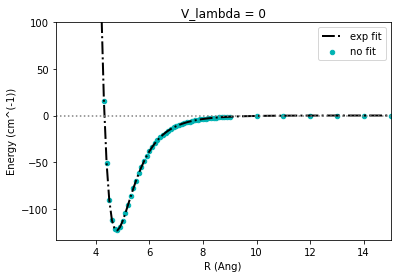

Double exponential RMSE =  2.9360116709938374e-14
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[0 2 2]]
Fitting coefficients for exp_fit function [a b c]:  [-1.40637274e+03  5.59887780e+03  1.18312686e+07]


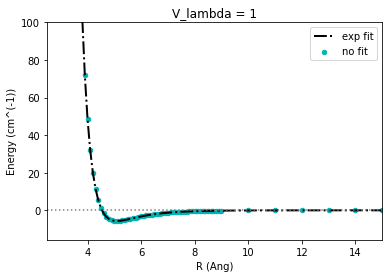

Double exponential RMSE =  2.464193108331383e-14
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[0 4 4]]
Fitting coefficients for exp_fit function [a b c]:  [-6.25733390e+00  2.03144554e+03 -3.92413421e+04]


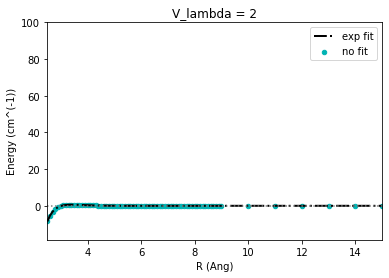

Double exponential RMSE =  2.2966692837228616e-14
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[2 0 2]]
Fitting coefficients for exp_fit function [a b c]:  [-3.64656921e+03 -2.98494070e+06  3.92062241e+08]


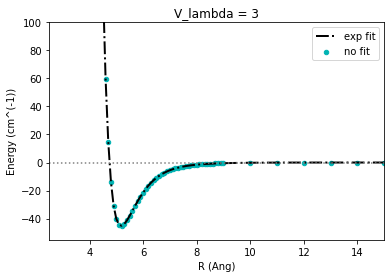

Double exponential RMSE =  5.0230951054899e-14
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[2 2 0]]
Fitting coefficients for exp_fit function [a b c]:  [-1.88360390e+04  7.05261006e+04  4.07928928e+07]


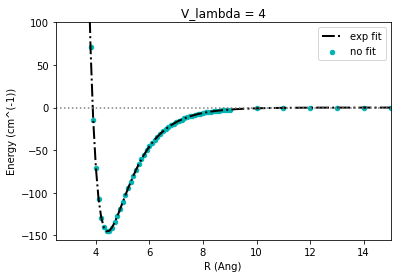

Double exponential RMSE =  1.115783223472832e-13
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[2 2 2]]
Fitting coefficients for exp_fit function [a b c]:  [ 9.18838094e+03 -2.42400323e+04 -2.26823615e+07]


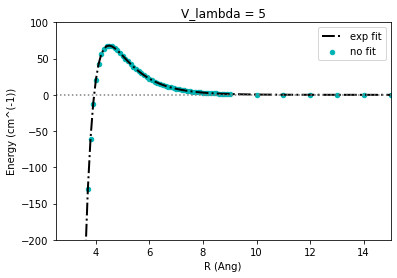

Double exponential RMSE =  5.3387116909517113e-14
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[2 2 4]]
Fitting coefficients for exp_fit function [a b c]:  [-7.24909384e+03  5.42022475e+03  2.44606112e+07]


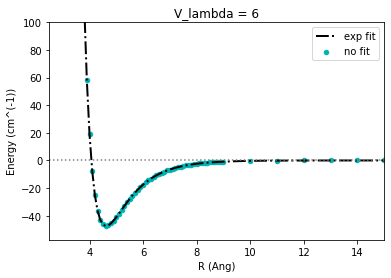

Double exponential RMSE =  5.1807835844767586e-14
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[2 4 2]]
Fitting coefficients for exp_fit function [a b c]:  [-2.62123185e+01 -1.85732521e+04  1.55633756e+06]


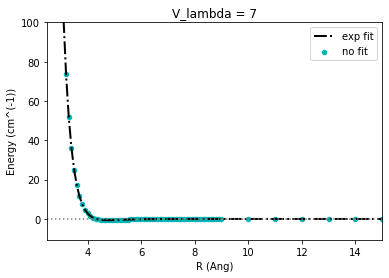

Double exponential RMSE =  5.907666627389463e-14
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[2 4 4]]
Fitting coefficients for exp_fit function [a b c]:  [ 8.08558752e+01  9.61667784e+03 -8.35004745e+05]


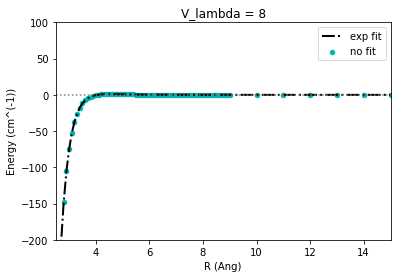

Double exponential RMSE =  4.84507714859844e-14
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[2 4 6]]
Fitting coefficients for exp_fit function [a b c]:  [-2.01255364e+02 -3.64628107e+03  4.33368520e+05]


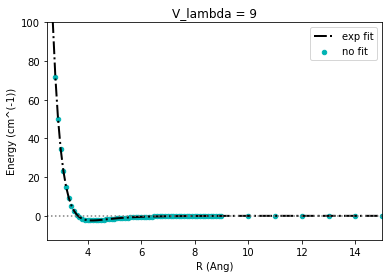

Double exponential RMSE =  5.0006134597757447e-14
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[4 0 4]]
Fitting coefficients for exp_fit function [a b c]:  [-3.47826511e+02 -1.40983275e+06  2.82436935e+08]


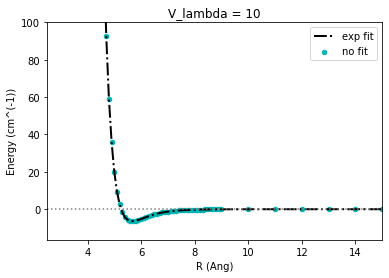

Double exponential RMSE =  5.810603296854112e-14
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[4 2 2]]
Fitting coefficients for exp_fit function [a b c]:  [-1.94029000e+03 -4.49909176e+05  4.66187231e+07]


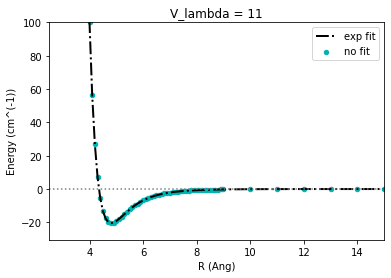

Double exponential RMSE =  1.027942978977837e-13
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[4 2 4]]
Fitting coefficients for exp_fit function [a b c]:  [ 1.96821465e+03  3.15127972e+05 -3.51864382e+07]


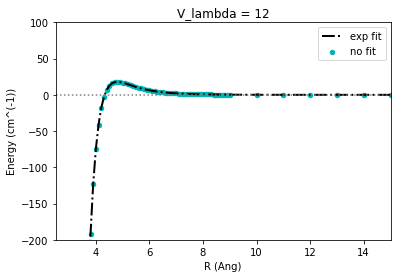

Double exponential RMSE =  7.689799282842131e-14
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[4 2 6]]
Fitting coefficients for exp_fit function [a b c]:  [-3.23027676e+03 -3.36633121e+05  4.22762914e+07]


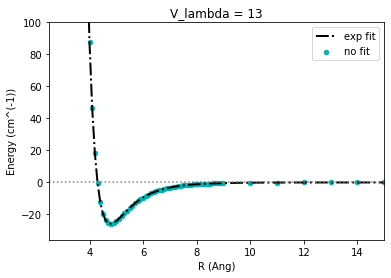

Double exponential RMSE =  8.503939975758442e-14
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[4 4 0]]
Fitting coefficients for exp_fit function [a b c]:  [ 4.12673344e+02 -1.54256629e+05  9.33945001e+06]


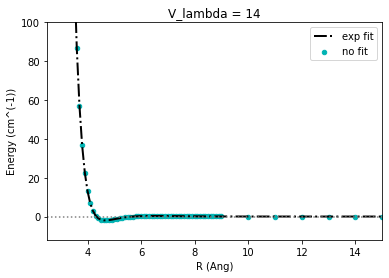

Double exponential RMSE =  1.7972853546931085e-13
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[4 4 2]]
Fitting coefficients for exp_fit function [a b c]:  [-2.18401148e+02  7.99867131e+04 -4.81373867e+06]


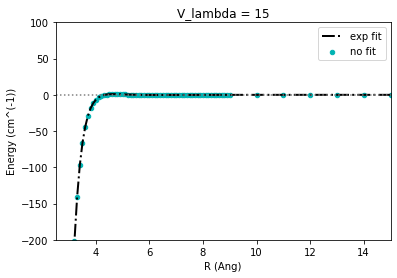

Double exponential RMSE =  9.218204328533662e-14
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[4 4 4]]
Fitting coefficients for exp_fit function [a b c]:  [ 1.82091097e+02 -6.55944929e+04  3.89898659e+06]


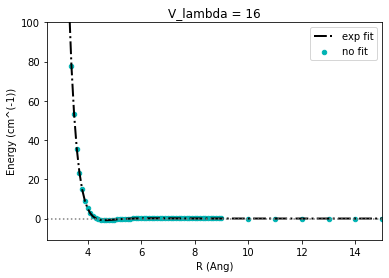

Double exponential RMSE =  8.088732323185387e-14
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[4 4 6]]
Fitting coefficients for exp_fit function [a b c]:  [-1.76849669e+02  6.44573997e+04 -3.77058421e+06]


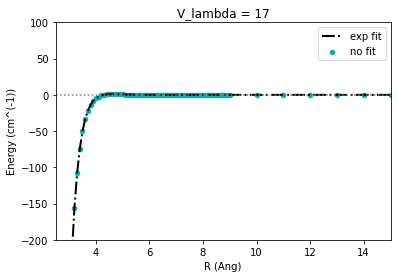

Double exponential RMSE =  7.980743600554324e-14
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[4 4 8]]
Fitting coefficients for exp_fit function [a b c]:  [ 2.29348111e+02 -8.31162650e+04  4.77300038e+06]


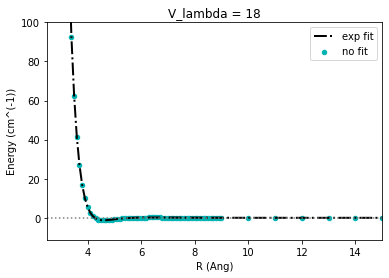

Double exponential RMSE =  1.1023459437365331e-13
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[6 0 6]]
Fitting coefficients for exp_fit function [a b c]:  [-3.67822610e+02 -3.55608148e+05  1.16940413e+08]


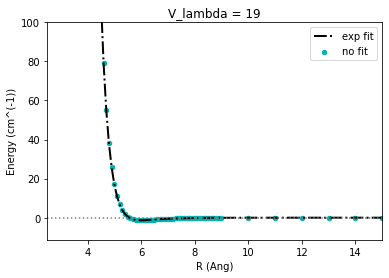

Double exponential RMSE =  4.89199487180495e-14
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[6 2 4]]
Fitting coefficients for exp_fit function [a b c]:  [-3.00617670e+03 -3.54816156e+05  3.81739556e+07]


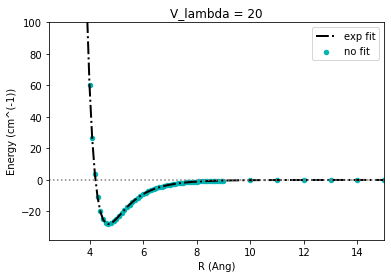

Double exponential RMSE =  8.180127207719861e-14
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[6 2 6]]
Fitting coefficients for exp_fit function [a b c]:  [ 5.57267647e+02  2.71691321e+05 -2.50455707e+07]


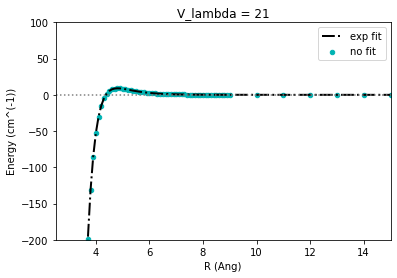

Double exponential RMSE =  5.490084283491686e-14
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[6 2 8]]
Fitting coefficients for exp_fit function [a b c]:  [ 2.00917667e+03 -3.19875872e+05  2.30628499e+07]


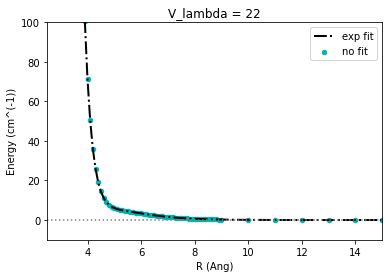

Double exponential RMSE =  4.6459350938432406e-14
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[6 4 2]]
Fitting coefficients for exp_fit function [a b c]:  [ 2.74844910e+02 -1.18523907e+05  7.37079846e+06]


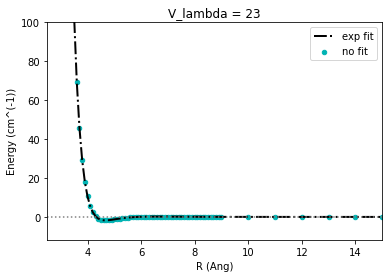

Double exponential RMSE =  1.4146428821444235e-13
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[6 4 4]]
Fitting coefficients for exp_fit function [a b c]:  [-1.54537707e+02  7.21918864e+04 -4.52789779e+06]


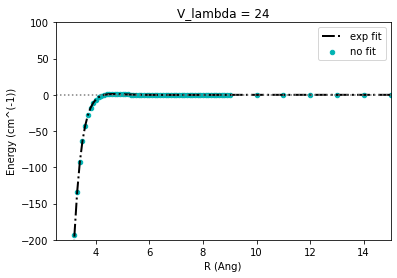

Double exponential RMSE =  8.411666895676046e-14
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[6 4 6]]
Fitting coefficients for exp_fit function [a b c]:  [ 9.26914586e+01 -5.29527161e+04  3.37596164e+06]


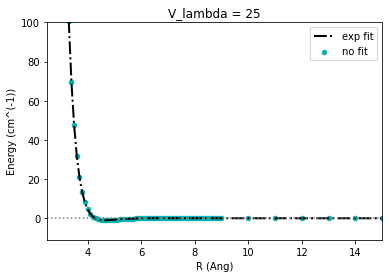

Double exponential RMSE =  6.544083666340005e-14
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[6 4 8]]
Fitting coefficients for exp_fit function [a b c]:  [-3.59063029e+01  3.93881797e+04 -2.59412406e+06]


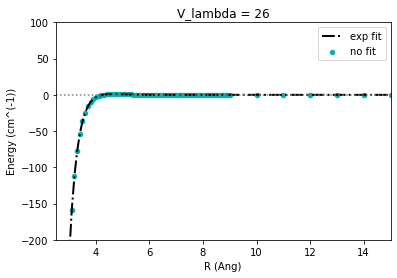

Double exponential RMSE =  4.957161022805794e-14
----------------------------------------------------------------------------------------------------


Radial coefficient [l1 l2 l]:  [[ 6  4 10]]
Fitting coefficients for exp_fit function [a b c]:  [-3.63584576e+01 -2.97658354e+04  2.12965111e+06]


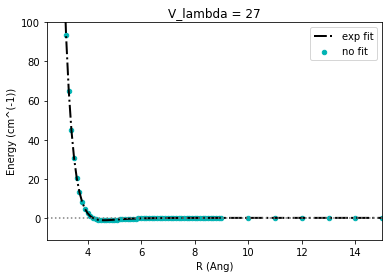

Double exponential RMSE =  4.57645005870441e-14
----------------------------------------------------------------------------------------------------


Average fit RMSE =  7.091512550646124e-14


In [50]:
strt=15     # starting point for fit (choose carefully)
for i in range(0,lm):
    j=int(i)
    y_dummy = df_Vnf[j]
    parsx, covx = curve_fit(f=exp_fit, xdata=x_dummy[strt:], ydata=y_dummy[strt:], p0=[0,0,1000])
    a[j],b[j],c[j] = parsx
    print("Radial coefficient [l1 l2 l]: ", Lmat[i])
    print("Fitting coefficients for exp_fit function [a b c]: ",parsx)
    
    # Plot the fit data as an overlay on the scatter data
    plt.scatter(x_dummy, y_dummy,s=20, color='#00b3b3',label = 'no fit')
    
    # new range for fitted curve
    xdummy=np.arange(2.5,15.1,0.1)
    plt.plot(xdummy, exp_fit(xdummy, *parsx), linestyle='-.', linewidth=2, color='black', label = 'exp fit')
    plt.legend(loc="upper right")
    plt.ylabel("Energy (cm^(-1))")
    plt.xlabel("R (Ang)")
    plt.axhline(y=0, color='grey', linestyle=':')
    plt.title("V_lambda = %d" %(i))
    plt.ylim(max(y_dummy.min()-10,-200), 100)
    plt.xlim(2.5, 15)
    plt.show()
    print('Double exponential RMSE = ',np.sqrt(np.average(np.power((exp_fit(x_dummy[strt:], 
                                                                            *parsx) - y_dummy[strt:]),2))))
    print('-----'*20)
    print('\n')
    rmsx[j]=np.sqrt(np.average(np.power((exp_fit(x_dummy[strt:], *parsx) - y_dummy[strt:]),2)))
print('Average fit RMSE = ',np.average(rmsx))

In [33]:
# save output for each V lambdas as required by molscat!
print('LAMBDA ='),
for j in range (lm):
    print(Lmat[j,0],',',Lmat[j,1],',',Lmat[j,2],',')
print('NTERM  = ', '3,'*lm)
print('NPOWER = ', '0,0,0'*int(lm))
print('A      = ')
for j in range (lm):
    print(a[j],',',b[j],',',c[j],',')
print('E      =', '-1,-2,-3,'*lm) # change as per funtion taken above

LAMBDA =
0 , 0 , 0 ,
0 , 2 , 2 ,
0 , 4 , 4 ,
2 , 0 , 2 ,
2 , 2 , 0 ,
2 , 2 , 2 ,
2 , 2 , 4 ,
2 , 4 , 2 ,
2 , 4 , 4 ,
2 , 4 , 6 ,
4 , 0 , 4 ,
4 , 2 , 2 ,
4 , 2 , 4 ,
4 , 2 , 6 ,
4 , 4 , 0 ,
4 , 4 , 2 ,
4 , 4 , 4 ,
4 , 4 , 6 ,
4 , 4 , 8 ,
6 , 0 , 6 ,
6 , 2 , 4 ,
6 , 2 , 6 ,
6 , 2 , 8 ,
6 , 4 , 2 ,
6 , 4 , 4 ,
6 , 4 , 6 ,
6 , 4 , 8 ,
6 , 4 , 10 ,
NTERM  =  3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,
NPOWER =  0,0,00,0,00,0,00,0,00,0,00,0,00,0,00,0,00,0,00,0,00,0,00,0,00,0,00,0,00,0,00,0,00,0,00,0,00,0,00,0,00,0,00,0,00,0,00,0,00,0,00,0,00,0,00,0,0
A      = 
-10243.658960821569 , -2760896.7152761635 , 265282132.5224896 ,
-1406.3727365810014 , 5598.877801774036 , 11831268.567441955 ,
-6.257333899641203 , 2031.4455379371025 , -39241.342105182404 ,
-3646.5692110700666 , -2984940.699005867 , 392062241.0591076 ,
-18836.038979439185 , 70526.10058373635 , 40792892.82353207 ,
9188.38094052417 , -24240.032258620377 , -22682361.46467987 ,
-7249.093844538835 , 5420.22474737047 , 24460611

## For more functions/options to fit radial coefficients, see: 
### CODE_4_MP_fit.ipynb
    The jupyter-notebook contains 3 common functions and fits 2D radial coefficients.